In [1]:
import torch
import torchmetrics
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as T
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

In [2]:
#numbers
mnist = torchvision.datasets.MNIST

ToTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_data, valid_data = random_split(mnist(root='datasets', train=True, download=True, transform=ToTensor), lengths=[0.9, 0.1])
test_data = mnist(root='datasets', train=False, download=True, transform=ToTensor)

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=64)
test_dataloader  = DataLoader(test_data, batch_size=64)

In [3]:
train_data[0][0].size()

torch.Size([1, 28, 28])

In [16]:
class ResidualUnit(nn.Module):
    def __init__(self, in_features, out_features, stride=1, padding=1, kernel_size=3):
        super().__init__()
        self.module = nn.Sequential(nn.Conv2d(in_features, out_features, stride=stride, kernel_size=kernel_size, padding=padding, bias=False), nn.BatchNorm2d(out_features), nn.ReLU(), 
                                    nn.Conv2d(out_features, out_features, stride=1, kernel_size=kernel_size, padding=padding, bias=False), nn.BatchNorm2d(out_features))
        if stride > 1:
            self.skip_connection = nn.Sequential(nn.Conv2d(in_features, out_features, kernel_size=1, stride=stride, padding=0), nn.BatchNorm2d(out_features))
        else:
            self.skip_connection = nn.Identity()
            
    def forward(self, X):
        return F.relu(self.module(X) + self.skip_connection(X))

In [17]:
class ResNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        layers = [nn.Conv2d(in_channels, 16, stride=1, kernel_size=5, padding='same', bias=False), nn.BatchNorm2d(16),
                  nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=1)]
        prev_filter_num = 16
        stride = 1
        for filter_num in [16] * 4 + [32] * 4 + [64] *2:
            if prev_filter_num != filter_num:
                stride = 2
            layers += [ResidualUnit(prev_filter_num, filter_num, stride=stride)]
            
            prev_filter_num = filter_num
            stride = 1
            
        layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.LazyLinear(10)]
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, X):
        return self.model(X)

In [6]:
def train(model, optimizer, criterion, data_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad()
        
        mean_loss = total_loss / len(data_loader)
        print(f"epoch: {epoch}   loss: {mean_loss}")

In [7]:
def evaluate(model, metric, data_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
            
    return metric.compute()

In [18]:
resnet = ResNet().to('cuda')
#optimizer = torch.optim.NAdam(params=resnet.parameters, lr=0.002)
optimizer = torch.optim.Adam(params=resnet.parameters(), lr=0.001, betas=(0.9, 0.999))
xentropy = nn.CrossEntropyLoss()


train(resnet, optimizer, xentropy, train_dataloader, 15)

epoch: 0   loss: 0.16088373590287228
epoch: 1   loss: 0.05103212986853177
epoch: 2   loss: 0.03901544807095884
epoch: 3   loss: 0.034102243337514306
epoch: 4   loss: 0.028012944637826463
epoch: 5   loss: 0.025945304746713912
epoch: 6   loss: 0.02158875657735592
epoch: 7   loss: 0.021830898731561008
epoch: 8   loss: 0.017685596149961545
epoch: 9   loss: 0.017672669128527586
epoch: 10   loss: 0.014024268085092112
epoch: 11   loss: 0.014803913968487783
epoch: 12   loss: 0.013085322039324892
epoch: 13   loss: 0.011446686162688954
epoch: 14   loss: 0.011965251738651834


In [19]:
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to('cuda')
evaluate(resnet, accuracy, valid_dataloader)

tensor(0.9913, device='cuda:0')

In [30]:
def inc_dcit_of_lists(dictx, key, increment):
    result = []
    for value in dictx[key]:
        result.append(value + increment) 
    dictx[key] = result
    return dictx
        
dict3 = {'a':[65, 97], 'b':[66, 98], 'c':[69, 101]}

dict3 = inc_dcit_of_lists(dict3, 'b', -2)
dict3

{'a': [65, 97], 'b': [64, 96], 'c': [69, 101]}

# 9

In [34]:
import torch.backends.cudnn as cudnn
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

In [35]:
data_transformer = {'train' : T.Compose([T.RandomResizedCrop(224), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
                'val' : T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])}

data_dir = 'datasets/insects'
image_datasets = {x: torchvision.datasets.ImageFolder(os.path.join(data_dir, x), data_transformer[x]) for x in ['train', 'val']}
data_loaders = {x: DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=4) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'using {device}')

using cuda


/home/damian/test/test/lib/python3.14/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


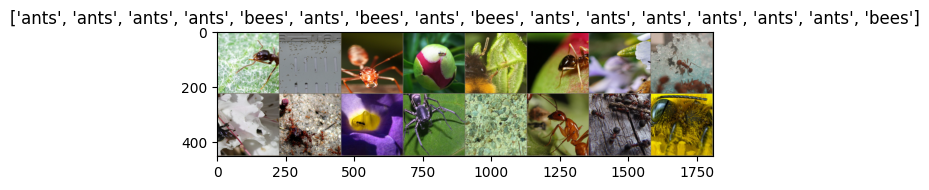

In [36]:
def imshow(X, title=None):
    X = X.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    X = X * std + mean
    X = np.clip(X, 0, 1)
    plt.imshow(X)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)
    
inputs, classes = next(iter(data_loaders['train']))
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [37]:
def train(model, optimizer, criterion, scheduler, data_loader, dataset_sizes, n_epochs=30):
    since = time.time()
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        
        best_acc = 0.0
        
        for epoch in range(n_epochs):
            print(f'Epoch {epoch}/{n_epochs}')
            print('-'*10)
            
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                elif phase == 'val':
                    model.eval()
                
                running_loss = 0.0
                running_corects = 0.0
                
                for X_batch, y_batch in data_loader[phase]:
                    X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase=='train'):
                        y_pred = model(X_batch)
                        loss = criterion(y_pred, y_batch)
                        _, preds = torch.max(y_pred, 1)
                        
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                            
                    running_loss += loss.item() * y_batch.size(0)
                    running_corects += torch.sum(preds==y_batch.data)
                    
                if phase == 'train':
                    scheduler.step() 
                
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corects.double() / dataset_sizes[phase]
                print(f'{phase} loss: {epoch_loss:.4f}, accuracy: {epoch_acc:.4f}')
                
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
            print()
        time_elapsed = time.time() - since
        print(f'Training finished in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best score: {best_acc:.4f}')
    
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [43]:
def visualize_model(model, data_loaders, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()
    
    with torch.no_grad():
        for i, (X_batch, y_batch) in enumerate(data_loaders['val']):
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            
            y_pred = model(X_batch)
            _, preds = torch.max(y_pred, 1)
            
            for j in range(y_batch.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted {class_names[preds[j]]}')
                imshow(X_batch.cpu().data[j])
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
            model.train(mode=was_training)

In [39]:
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features

model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to('cuda')

xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [40]:
train(model, optimizer, xentropy, scheduler, data_loaders, dataset_sizes)

Epoch 0/30
----------
train loss: 0.7479, accuracy: 0.5246
val loss: 0.3368, accuracy: 0.9150

Epoch 1/30
----------
train loss: 0.2852, accuracy: 0.8975
val loss: 0.2054, accuracy: 0.9477

Epoch 2/30
----------
train loss: 0.2135, accuracy: 0.9303
val loss: 0.1855, accuracy: 0.9346

Epoch 3/30
----------
train loss: 0.2087, accuracy: 0.9180
val loss: 0.1544, accuracy: 0.9542

Epoch 4/30
----------
train loss: 0.1884, accuracy: 0.9139
val loss: 0.1593, accuracy: 0.9477

Epoch 5/30
----------
train loss: 0.2702, accuracy: 0.8975
val loss: 0.1805, accuracy: 0.9608

Epoch 6/30
----------
train loss: 0.1518, accuracy: 0.9467
val loss: 0.1560, accuracy: 0.9477

Epoch 7/30
----------
train loss: 0.1360, accuracy: 0.9467
val loss: 0.1585, accuracy: 0.9412

Epoch 8/30
----------
train loss: 0.1445, accuracy: 0.9467
val loss: 0.1525, accuracy: 0.9412

Epoch 9/30
----------
train loss: 0.1743, accuracy: 0.9508
val loss: 0.1657, accuracy: 0.9477

Epoch 10/30
----------
train loss: 0.1125, accurac

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

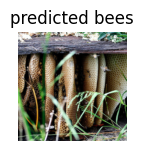

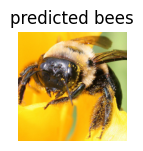

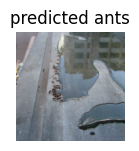

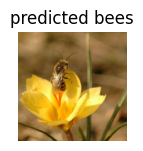

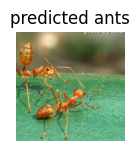

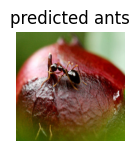

In [44]:
visualize_model(model, data_loaders)

In [46]:
model_2 = torchvision.models.resnet18(weights="IMAGENET1K_V1")
for param in model_2.parameters():
    param.requires_grad = False
    
num_ftrs = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, len(class_names))
model_2 = model_2.to('cuda')

xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_2 = train(model_2, optimizer, xentropy, scheduler, data_loaders, dataset_sizes)

Epoch 0/30
----------
train loss: 0.5859, accuracy: 0.6516
val loss: 0.4208, accuracy: 0.8758

Epoch 1/30
----------
train loss: 0.4220, accuracy: 0.8238
val loss: 0.2993, accuracy: 0.9020

Epoch 2/30
----------
train loss: 0.3504, accuracy: 0.8279
val loss: 0.2435, accuracy: 0.9281

Epoch 3/30
----------
train loss: 0.2643, accuracy: 0.8893
val loss: 0.2486, accuracy: 0.9020

Epoch 4/30
----------
train loss: 0.3064, accuracy: 0.8607
val loss: 0.1995, accuracy: 0.9412

Epoch 5/30
----------
train loss: 0.2719, accuracy: 0.8730
val loss: 0.1899, accuracy: 0.9412

Epoch 6/30
----------
train loss: 0.2535, accuracy: 0.8852
val loss: 0.1789, accuracy: 0.9542

Epoch 7/30
----------
train loss: 0.2018, accuracy: 0.9262
val loss: 0.1766, accuracy: 0.9608

Epoch 8/30
----------
train loss: 0.1999, accuracy: 0.9303
val loss: 0.1833, accuracy: 0.9542

Epoch 9/30
----------
train loss: 0.2106, accuracy: 0.9303
val loss: 0.1807, accuracy: 0.9542

Epoch 10/30
----------
train loss: 0.2208, accurac

# 10

In [5]:
import torch
import torchmetrics
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

from torch.utils.data import DataLoader, random_split

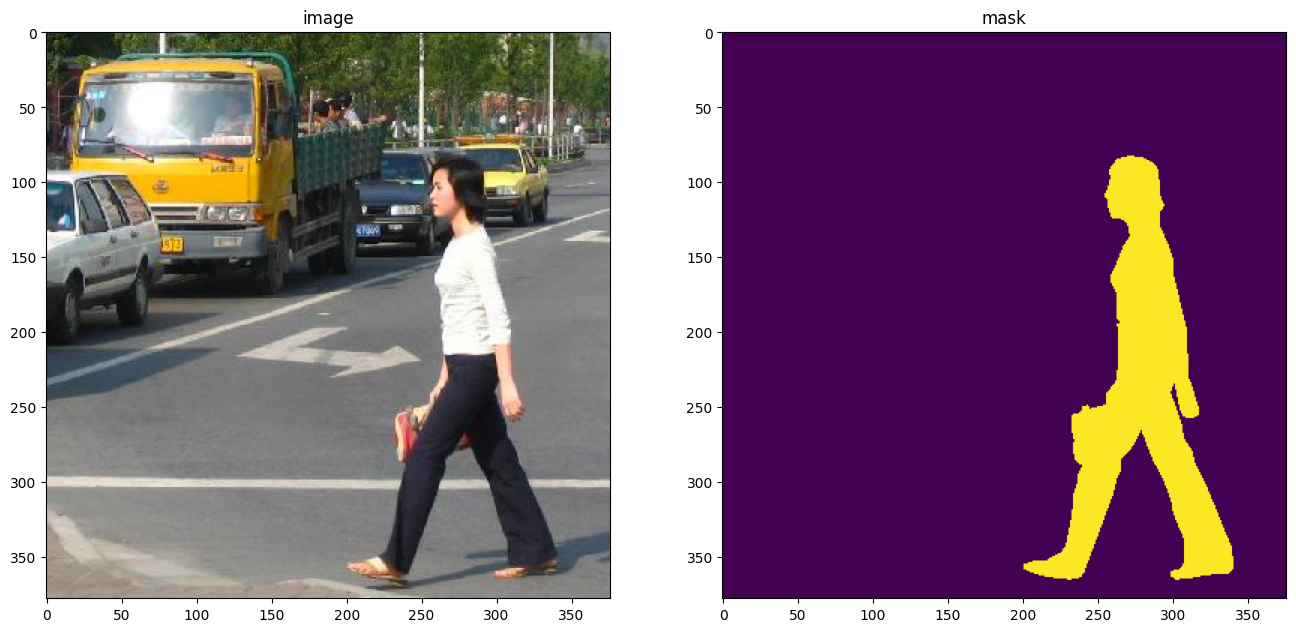

In [4]:
image = torchvision.io.read_image('datasets/PennFudanPed/PNGImages/FudanPed00023.png')
mask = torchvision.io.read_image('datasets/PennFudanPed/PedMasks/FudanPed00023_mask.png')

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title('image')
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title('mask')
plt.imshow(mask.permute(1, 2, 0))

In [6]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        
        self.imgs = list(sorted(os.listdir(os.path.join(root, 'PNGImages'))))
        self.masks = list(sorted(os.listdir(os.path.join(root, 'PedMasks'))))
        
    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'PNGImages', self.imgs[idx])
        mask_path = os.path.join(self.root, 'PedMasks', self.masks[idx])
        img = torchvision.io.read_image(img_path)
        mask = torchvision.io.read_image(mask_path)
        
        obj_ids = torch.unique(mask)
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)
        
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        boxes = torchvision.ops.masks_to_boxes(masks)
        labels = torch.ones((num_objs), dtype=torch.int64)
        
        img_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        iscrowd = torch.zeros((num_objs), dtype=torch.int64)
        
        img = torchvision.tv_tensors.Image(img)
        
        target = {}
        target["boxes"] = torchvision.tv_tensors.BoundingBoxes(boxes, format='XYXY', canvas_size=T.functional.get_size(img))
        target["masks"] = torchvision.tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = img_id
        target["area"] = area
        target["iscrowd"] = iscrowd
        
        if self.transforms != None:
            img, target = self.transforms(img, target)
            
        return img, target
    
    def __len__(self):
        return len(self.imgs)

In [7]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 2

model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/damian/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [01:36<00:00, 1.74MB/s] 


In [8]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

backbone = torchvision.models.mobilenet_v2(weights='DEFAULT').features
backbone.out_channels=1280

anchor_generator = AnchorGenerator(sizes=(32, 64, 128, 256, 512), aspect_ratios=(0.5, 1.0, 2.0))

roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'], output_size=7, sampling_ratio=2)

model = FasterRCNN(backbone, num_classes, rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/damian/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:12<00:00, 1.18MB/s]


In [9]:
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    
    return model

In [10]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

--2026-03-24 21:35:34--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4063 (4.0K) [text/plain]
Saving to: ‘engine.py’

     0K ...                                                   100%  226K=0.02s

2026-03-24 21:35:35 (226 KB/s) - ‘engine.py’ saved [4063/4063]

--2026-03-24 21:35:35--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|

0

In [11]:
def get_transforms(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(dtype=torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [12]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
dataset = PennFudanDataset('datasets/PennFudanPed', get_transforms(train=True))
data_loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=utils.collate_fn)

#training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
targets_pred = model(images, targets)
print(targets_pred)

#eval (inference)
model.eval()
x = [torch.rand((3, 300, 400)), torch.rand((3, 600, 500))]
y_pred = model(x)
print(y_pred[0])

{'loss_classifier': tensor(0.1300, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0386, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0156, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0027, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


In [16]:
from engine import train_one_epoch, evaluate

device = 'cuda'

train_dataset = PennFudanDataset('datasets/PennFudanPed', transforms=get_transforms(train=True))
test_dataset  = PennFudanDataset('datasets/PennFudanPed', transforms=get_transforms(train=False))

indeces = torch.randperm(len(train_dataset)).tolist()
train_dataset = torch.utils.data.Subset(train_dataset, indeces[:-50])
test_dataset = torch.utils.data.Subset(test_dataset, indeces[:-50])

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn)
test_dataloader  = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=utils.collate_fn)

model = get_model_instance_segmentation(num_classes)
model = model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 5
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_dataloader, device, epoch, print_freq=10)
    lr_scheduler.step()
    
    evaluate(model, test_dataloader, device)
    
print('Finish!')

Epoch: [0]  [ 0/60]  eta: 0:00:30  lr: 0.000090  loss: 4.2849 (4.2849)  loss_classifier: 0.8125 (0.8125)  loss_box_reg: 0.3036 (0.3036)  loss_mask: 3.1057 (3.1057)  loss_objectness: 0.0574 (0.0574)  loss_rpn_box_reg: 0.0058 (0.0058)  time: 0.5019  data: 0.0160  max mem: 5122
Epoch: [0]  [10/60]  eta: 0:00:24  lr: 0.000936  loss: 1.6634 (2.1883)  loss_classifier: 0.5155 (0.4773)  loss_box_reg: 0.2576 (0.2685)  loss_mask: 0.8950 (1.4082)  loss_objectness: 0.0267 (0.0282)  loss_rpn_box_reg: 0.0049 (0.0061)  time: 0.4875  data: 0.0174  max mem: 5122
Epoch: [0]  [20/60]  eta: 0:00:20  lr: 0.001783  loss: 1.0559 (1.5397)  loss_classifier: 0.2260 (0.3514)  loss_box_reg: 0.2582 (0.2839)  loss_mask: 0.3386 (0.8745)  loss_objectness: 0.0203 (0.0219)  loss_rpn_box_reg: 0.0059 (0.0080)  time: 0.5095  data: 0.0173  max mem: 5122
Epoch: [0]  [30/60]  eta: 0:00:15  lr: 0.002629  loss: 0.5545 (1.1994)  loss_classifier: 0.1025 (0.2609)  loss_box_reg: 0.2567 (0.2601)  loss_mask: 0.2141 (0.6535)  loss_ob

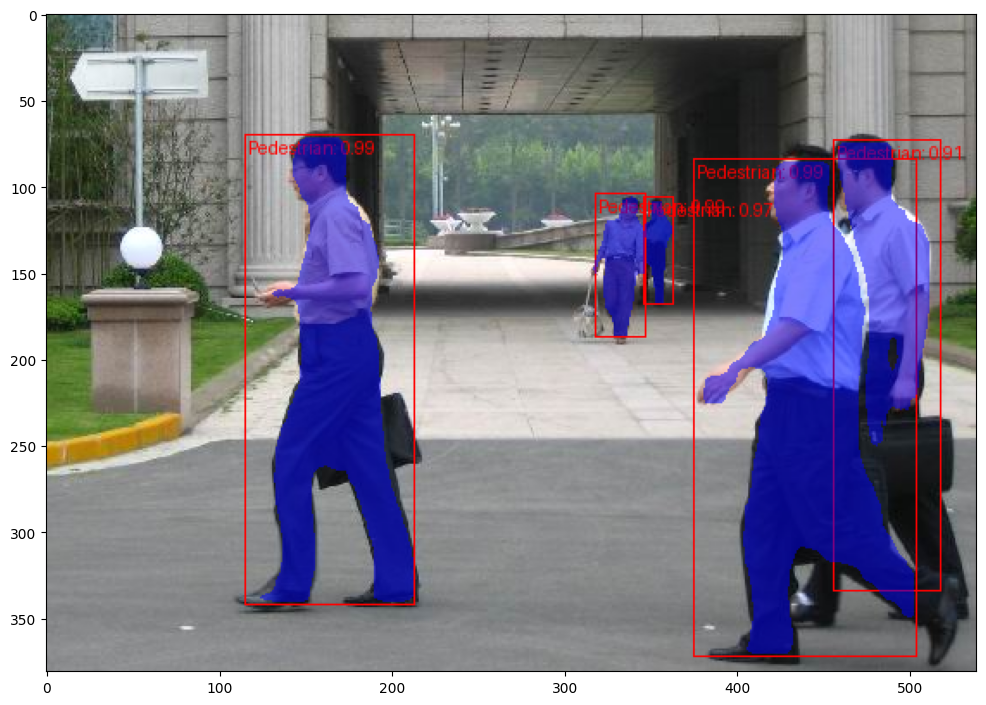

In [19]:
image = torchvision.io.read_image('datasets/PennFudanPed/PNGImages/FudanPed00007.png')
eval_transform = get_transforms(False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to('cuda')
    y_preds = model([x])
    y_pred = y_preds[0]
    
image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

pred_labels = [f"Pedestrian: {score:.2f}" for label, score in zip(y_pred['labels'], y_pred['scores'])]
pred_boxes = y_pred['boxes'].long()
output_image = torchvision.utils.draw_bounding_boxes(image, pred_boxes, pred_labels, colors='red')

masks = (y_pred['masks'] > 0.7).squeeze(1)
output_image = torchvision.utils.draw_segmentation_masks(output_image, masks, alpha=0.5, colors='blue')

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))